Analyzing how adding Al affects density of ['Fe', 'O'] compounds...



Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Found 2 base compounds and 1 with added Al.


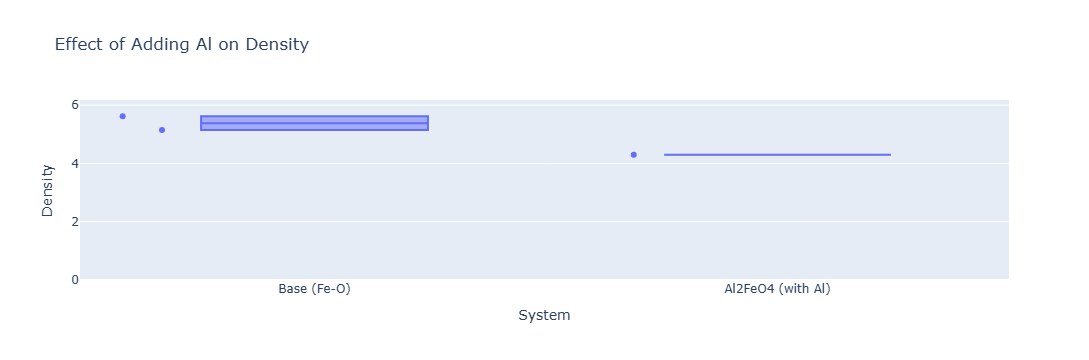

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from mp_api.client import MPRester
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

API_KEY = "YOUR_API_KEY_HERE"  # Replace with your Materials Project API key

def analyze_element_effect(base_elements, added_element):

    #Compare density of materials that contain only base_elements vs those that also contain added_element.
    #Example: base_elements = ["Fe", "O"], added_element = "Al"
    
    print(f"Analyzing how adding {added_element} affects density of {base_elements} compounds...\n")

    with MPRester(API_KEY) as mpr:
        # Searches the database for base system materials
        base_docs = mpr.materials.summary.search(
            chemsys="-".join(base_elements),
            is_stable=True,
            fields=["material_id", "formula_pretty", "density"]
        )

        # Searches the database for the material with added element
        extended_chemsys = base_elements + [added_element]
        added_docs = mpr.materials.summary.search(
            chemsys="-".join(sorted(extended_chemsys)),
            is_stable=True,
            fields=["material_id", "formula_pretty", "density"]
        )

    # Converts it to DataFrames
    base_df = pd.DataFrame([{ "Formula": d.formula_pretty, "Density": d.density } for d in base_docs])
    added_df = pd.DataFrame([{ "Formula": d.formula_pretty, "Density": d.density } for d in added_docs])

    print(f"Found {len(base_df)} base compounds and {len(added_df)} with added {added_element}.")

    # Adds labels for plotting
    base_df["System"] = f"Base ({'-'.join(base_elements)})"
    added_df["System"] = added_df["Formula"] + f" (with {added_element})"

    combined_df = pd.concat([base_df, added_df], ignore_index=True)

    # Plots density for comparison
    fig = px.box(
    combined_df.dropna(subset=["Density"]),
    x="System",
    y="Density",
    title=f"Effect of Adding {added_element} on Density",
    points="all"
    )
    fig.update_layout(yaxis=dict(range=[0, combined_df["Density"].max() * 1.1]))

    fig.show()

    return combined_df

if __name__ == "__main__":
    # Change the elements in quotations to whatever is wanted.
    analyze_element_effect(["Fe", "O"], "Al")

